## ResNet50 Threshold Sensitivity Analysis
This notebook analyzes one hyperparameter: the classification threshold.
It uses saved test probabilities and plots Sensitivity vs Specificity across thresholds.

### Inputs
Expected file columns: `y_true`, `y_prob`
Preferred file: `resnet50_pneumothorax_cv_test_predictions.csv`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [2]:
PRED_PATH_MAIN = Path('resnet50_pneumothorax_cv_test_predictions.csv')
THRESHOLD_FILE = Path('resnet50_pneumothorax_test_threshold.txt')

if PRED_PATH_MAIN.exists():
    pred_path = PRED_PATH_MAIN
else:
    raise FileNotFoundError('Could not find test predictions CSV.')

pred_df = pd.read_csv(pred_path)
required_cols = {'y_true', 'y_prob'}
if not required_cols.issubset(pred_df.columns):
    raise ValueError(f'Missing required columns: {required_cols}')

pred_df = pred_df[['y_true', 'y_prob']].dropna().copy()
pred_df['y_true'] = pred_df['y_true'].astype(int)

print(f'Loaded: {pred_path}')
print(f'Rows: {len(pred_df):,}')
print(pred_df.head())


Loaded: resnet50_pneumothorax_cv_test_predictions.csv
Rows: 1,134
   y_true    y_prob
0       0  0.137089
1       0  0.264494
2       0  0.157291
3       0  0.702576
4       0  0.216495


In [3]:
def sens_spec(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return sensitivity, specificity, tn, fp, fn, tp

thresholds = np.linspace(0.05, 0.95, 91)
rows = []

for t in thresholds:
    sens, spec, tn, fp, fn, tp = sens_spec(
        pred_df['y_true'].to_numpy(),
        pred_df['y_prob'].to_numpy(),
        t,
    )
    rows.append({
        'threshold': float(t),
        'sensitivity': float(sens),
        'specificity': float(spec),
        'youden_j': float(sens + spec - 1),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    })

curve_df = pd.DataFrame(rows)

# Primary highlighted operating point: max Youden's J
best_idx = int(curve_df['youden_j'].idxmax())
best_row = curve_df.loc[best_idx]

# Optional reference threshold from training artifact
ref_threshold = None
if THRESHOLD_FILE.exists():
    try:
        ref_threshold = float(THRESHOLD_FILE.read_text(encoding='utf-8').strip())
    except Exception:
        ref_threshold = None

curve_df.head()


,threshold,sensitivity,specificity,youden_j,tn,fp,fn,tp
0,0.05,1.0,0.001010,0.001010,1,989,0,144
1,0.06,1.0,0.003030,0.003030,3,987,0,144
2,0.07,1.0,0.004040,0.004040,4,986,0,144
3,0.08,1.0,0.007071,0.007071,7,983,0,144
4,0.09,1.0,0.010101,0.010101,10,980,0,144


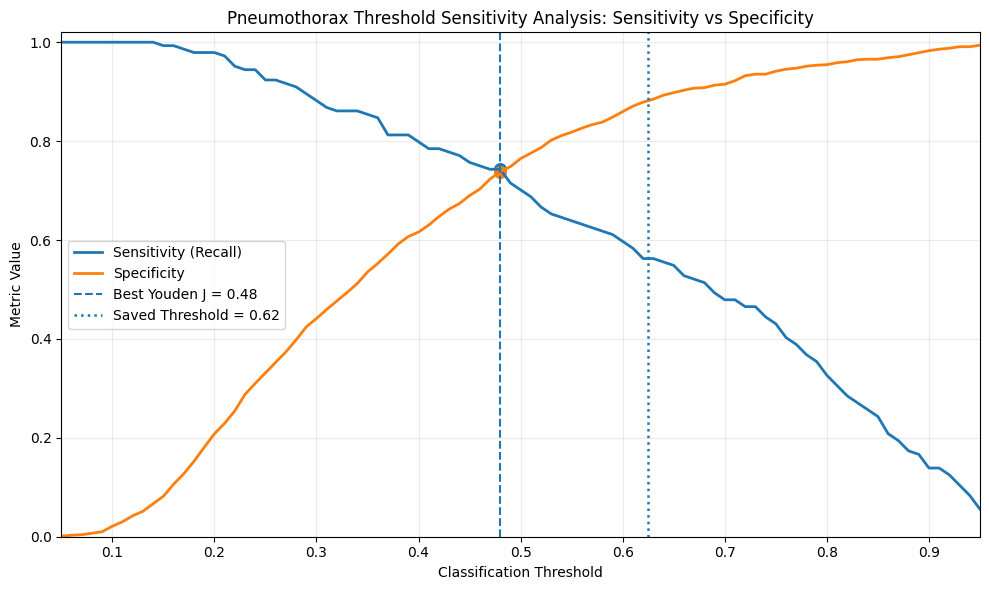

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(curve_df['threshold'], curve_df['sensitivity'], label='Sensitivity (Recall)', linewidth=2)
plt.plot(curve_df['threshold'], curve_df['specificity'], label='Specificity', linewidth=2)

plt.scatter([best_row['threshold']], [best_row['sensitivity']], s=70)
plt.scatter([best_row['threshold']], [best_row['specificity']], s=70)
plt.axvline(best_row['threshold'], linestyle='--', linewidth=1.5,
            label=f"Best Youden J = {best_row['threshold']:.2f}")

if ref_threshold is not None:
    plt.axvline(ref_threshold, linestyle=':', linewidth=1.8,
                label=f"Saved Threshold = {ref_threshold:.2f}")

plt.title('Pneumothorax Threshold Sensitivity Analysis: Sensitivity vs Specificity')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.ylim(0, 1.02)
plt.xlim(0.05, 0.95)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
summary = {
    'best_threshold_youden_j': float(best_row['threshold']),
    'best_sensitivity': float(best_row['sensitivity']),
    'best_specificity': float(best_row['specificity']),
    'best_youden_j': float(best_row['youden_j']),
}

print('Summary:')
for k, v in summary.items():
    print(f'- {k}: {v:.4f}')

out_curve = Path('resnet50_pneumothorax_threshold_sensitivity_curve.csv')
curve_df.to_csv(out_curve, index=False)
print(f'Saved curve data: {out_curve}')


Summary:
- best_threshold_youden_j: 0.4800
- best_sensitivity: 0.7431
- best_specificity: 0.7384
- best_youden_j: 0.4814
Saved curve data: resnet50_pneumothorax_threshold_sensitivity_curve.csv
